# 🤖 Diabetes Risk Prediction — Model Training, Evaluation & Selection

**Project**: Diabetes Risk Detection & Machine Learning Pipeline
**Input Dataset**: `data/processed/engineered_diabetes_risk_dataset.csv` (50,000 records, 75 features + target)
**Output Artifacts**: `models/diabetes_risk_model.pkl`, `models/model_metadata.json`, `reports/figures/*.png`

---

## 📌 Executive Summary & Objectives

With a clean, leakage-free and feature-engineered matrix in place, this notebook trains and compares candidate classifiers for the 3-tier `Diabetes_Risk` target (**Low**, **Moderate**, **High**), selects the best model, and exports it for the serving layer (`app/`).

### ⚠️ The Core Challenge: Severe Class Imbalance
The target is heavily skewed — `High` ≈ 73%, `Moderate` ≈ 26%, `Low` < 1% (470 patients). Plain accuracy is therefore misleading: a model that always predicts `High` already scores ~73%. We optimise and report:
- **Macro F1-score** (primary metric) — every tier contributes equally, so the rare `Low` tier cannot be ignored.
- **Balanced Accuracy** — mean per-class recall.
- **Per-class Recall / Precision** — clinically, missing a `High`-risk patient is the costliest error.

### 🎯 Key Workflow Stages
1. **Data Ingestion & Stratified Train/Test Split** (80/20, held-out test set untouched until the end).
2. **Baseline Models** — Dummy (majority class) and Logistic Regression.
3. **Candidate Model Comparison** — Logistic Regression, Random Forest, Histogram Gradient Boosting, all with class-imbalance handling, via 5-fold stratified cross-validation.
4. **Hyperparameter Tuning** of the best candidate (randomised search, macro-F1 objective).
5. **Held-out Test Evaluation** — classification report, confusion matrix, one-vs-rest ROC & Precision-Recall curves.
6. **Model Interpretability** — permutation feature importance.
7. **Model Export** — persisted pipeline + metadata for inference.

In [1]:
# Cell 1: Environment Setup, Libraries, & Plotting Configurations
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (auc, average_precision_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

# Styling & Warning Configurations
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Project Paths (notebook lives in notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'engineered_diabetes_risk_dataset.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = 'Diabetes_Risk'
CLASS_ORDER = ['Low', 'Moderate', 'High']              # ordinal clinical order
LABEL_MAP = {label: i for i, label in enumerate(CLASS_ORDER)}
palette = {'High': '#e74c3c', 'Moderate': '#f39c12', 'Low': '#2ecc71'}

print(f"✅ Modeling Stack Loaded: scikit-learn {sklearn.__version__}, pandas {pd.__version__}")
print(f"📁 Project Root: {PROJECT_ROOT}")

✅ Modeling Stack Loaded: scikit-learn 1.8.0, pandas 3.0.3
📁 Project Root: C:\Users\Chris\Desktop\diabetes-risk


## 1. Data Ingestion & Stratified Train/Test Split

We load the engineered feature matrix, encode the target in its **clinical order** (`Low`=0, `Moderate`=1, `High`=2) rather than alphabetically, and hold out 20% of patients as a **stratified** test set so that all three tiers — including the rare `Low` tier — appear in both splits in the same proportions.

In [2]:
# Cell 2: Data Ingestion & Stratified Split
df = pd.read_csv(DATA_PATH)
print(f"📥 Loaded Engineered Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing Cells: {df.isna().sum().sum()}")

X = df.drop(columns=[TARGET])
y = df[TARGET].map(LABEL_MAP).values
FEATURES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    'Train Count': pd.Series(y_train).value_counts().sort_index().values,
    'Train %': (pd.Series(y_train).value_counts(normalize=True).sort_index() * 100).round(2).values,
    'Test Count': pd.Series(y_test).value_counts().sort_index().values,
    'Test %': (pd.Series(y_test).value_counts(normalize=True).sort_index() * 100).round(2).values,
}, index=CLASS_ORDER)

print(f"\n🔀 Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows | Features: {len(FEATURES)}")
display(split_summary)

📥 Loaded Engineered Dataset: 50,000 rows x 76 columns
Missing Cells: 0



🔀 Train: 40,000 rows | Test: 10,000 rows | Features: 75


,Train Count,Train %,Test Count,Test %
Low,376,0.94,94,0.94
Moderate,10350,25.87,2587,25.87
High,29274,73.18,7319,73.19


## 2. Baseline Models

Before training anything sophisticated we establish reference points:
- **Dummy (Majority Class)** — always predicts `High`. Any useful model must clearly beat this.
- **Logistic Regression** (standardised features, `class_weight='balanced'`) — a simple, interpretable linear benchmark.

All candidates are evaluated with **5-fold stratified cross-validation on the training set only**.

In [3]:
# Cell 3: Cross-Validation Setup & Model Candidates
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'macro_f1': 'f1_macro',
    'balanced_acc': 'balanced_accuracy',
    'accuracy': 'accuracy',
    'roc_auc_ovr': 'roc_auc_ovr_weighted',
}

candidates = {
    'Dummy (Majority)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample', min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(
        class_weight='balanced', max_iter=300, learning_rate=0.1,
        early_stopping=True, random_state=RANDOM_STATE,
    ),
}

cv_results = {}
for name, model in candidates.items():
    start = time.time()
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_results[name] = {
        'Macro F1': scores['test_macro_f1'].mean(),
        'Macro F1 (std)': scores['test_macro_f1'].std(),
        'Balanced Accuracy': scores['test_balanced_acc'].mean(),
        'Accuracy': scores['test_accuracy'].mean(),
        'ROC-AUC (OvR, weighted)': scores['test_roc_auc_ovr'].mean(),
        'Fit Time (s)': scores['fit_time'].mean(),
    }
    print(f"✔ {name:<24} Macro F1 = {cv_results[name]['Macro F1']:.4f}  ({time.time() - start:.1f}s)")

cv_df = pd.DataFrame(cv_results).T.sort_values('Macro F1', ascending=False)
display(cv_df.round(4))

✔ Dummy (Majority)         Macro F1 = 0.2817  (0.7s)


✔ Logistic Regression      Macro F1 = 0.6857  (13.1s)


✔ Random Forest            Macro F1 = 0.5888  (138.4s)


✔ Hist Gradient Boosting   Macro F1 = 0.8099  (54.4s)


,Macro F1,Macro F1 (std),Balanced Accuracy,Accuracy,"ROC-AUC (OvR, weighted)",Fit Time (s)
Hist Gradient Boosting,0.8099,0.0147,0.8219,0.9287,0.9866,10.4083
Logistic Regression,0.6857,0.0045,0.8468,0.8428,0.9392,2.4731
Random Forest,0.5888,0.0077,0.5677,0.8916,0.9622,26.7979
Dummy (Majority),0.2817,0.0000,0.3333,0.7318,0.5000,0.0865


## 3. Candidate Model Comparison

We visualise the cross-validated scores. Note the gap between **Accuracy** and **Macro F1 / Balanced Accuracy** for the dummy model — this is exactly why accuracy alone is not a valid selection criterion on this dataset.

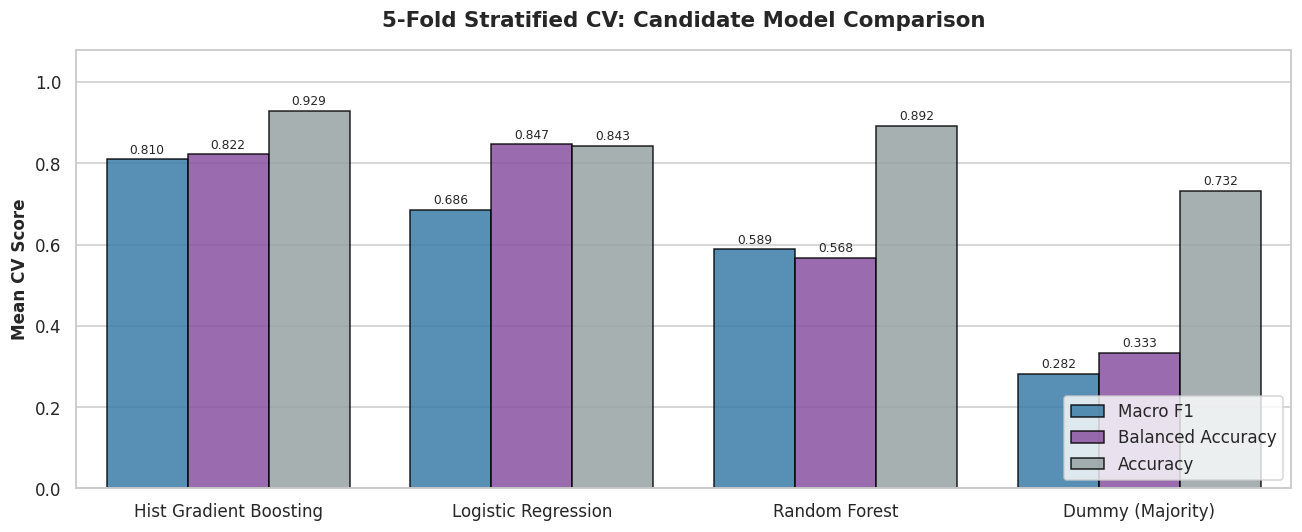

🏆 Best Candidate by CV Macro F1: Hist Gradient Boosting


In [4]:
# Cell 4: Visual Comparison of Cross-Validated Metrics
plot_df = cv_df[['Macro F1', 'Balanced Accuracy', 'Accuracy']].reset_index().melt(
    id_vars='index', var_name='Metric', value_name='Score'
).rename(columns={'index': 'Model'})

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', ax=ax,
            palette=['#2980b9', '#8e44ad', '#95a5a6'], edgecolor='black', alpha=0.85)
ax.set_title('5-Fold Stratified CV: Candidate Model Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Mean CV Score', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.08)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_cv.png', bbox_inches='tight')
plt.show()

best_candidate = cv_df.drop(index='Dummy (Majority)')['Macro F1'].idxmax()
print(f"🏆 Best Candidate by CV Macro F1: {best_candidate}")

## 4. Hyperparameter Tuning

We tune **Histogram Gradient Boosting** — the strongest family in the comparison above, fast on 40k rows, and natively robust to the skewed ratio features engineered in notebook 02.

A `RandomizedSearchCV` explores tree depth/size, learning rate, regularisation and iteration budget, optimising **macro F1** with 3-fold stratified CV. Class imbalance is handled through `class_weight='balanced'`.

In [5]:
# Cell 5: Randomised Hyperparameter Search (Hist Gradient Boosting)
param_distributions = {
    'learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
    'max_iter': [200, 400, 600],
    'max_leaf_nodes': [15, 31, 63],
    'max_depth': [None, 4, 6, 8],
    'min_samples_leaf': [10, 20, 40, 80],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', early_stopping=True,
                                   validation_fraction=0.1, n_iter_no_change=20,
                                   random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    verbose=0,
)

start = time.time()
search.fit(X_train, y_train)
print(f"⏱️ Search completed in {time.time() - start:.1f}s")
print(f"🏆 Best CV Macro F1: {search.best_score_:.4f}")
print("🔧 Best Hyperparameters:")
for k, v in search.best_params_.items():
    print(f"   {k:<20} {v}")

search_df = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
display(search_df[['rank_test_score', 'mean_test_score', 'std_test_score'] +
                  [f'param_{p}' for p in param_distributions]].head(8).round(4))

best_model = search.best_estimator_

⏱️ Search completed in 309.5s
🏆 Best CV Macro F1: 0.8078
🔧 Best Hyperparameters:
   min_samples_leaf     40
   max_leaf_nodes       31
   max_iter             200
   max_depth            4
   learning_rate        0.08
   l2_regularization    0.0


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_max_depth,param_min_samples_leaf,param_l2_regularization
8,1,0.8078,0.0152,0.08,200,31,4,40,0.0
18,2,0.8071,0.0236,0.10,600,15,4,80,0.1
7,3,0.8065,0.0155,0.10,400,15,6,40,0.1
4,4,0.8030,0.0076,0.05,400,31,4,40,0.5
10,5,0.8019,0.0100,0.15,200,63,8,80,0.5
13,6,0.8000,0.0214,0.03,400,15,4,20,0.1
3,7,0.7989,0.0137,0.08,400,15,6,80,0.1
2,8,0.7961,0.0168,0.08,400,15,8,40,0.1


## 5. Held-Out Test Set Evaluation

The tuned model is evaluated **once** on the 10,000 untouched test patients. We compare it against the untuned Logistic Regression baseline so the gain from model complexity is explicit.

In [6]:
# Cell 6: Test Set Metrics & Classification Report
baseline = candidates['Logistic Regression'].fit(X_train, y_train)

def evaluate(model, name):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    return {
        'Model': name,
        'Macro F1': f1_score(y_test, pred, average='macro'),
        'Weighted F1': f1_score(y_test, pred, average='weighted'),
        'Balanced Accuracy': balanced_accuracy_score(y_test, pred),
        'Accuracy': (pred == y_test).mean(),
        'ROC-AUC (OvR, macro)': roc_auc_score(y_test, proba, multi_class='ovr', average='macro'),
    }, pred, proba

base_metrics, _, _ = evaluate(baseline, 'Logistic Regression (baseline)')
best_metrics, y_pred, y_proba = evaluate(best_model, 'Tuned Hist Gradient Boosting')

test_df = pd.DataFrame([base_metrics, best_metrics]).set_index('Model')
display(test_df.round(4))

print("\n=== CLASSIFICATION REPORT: TUNED HIST GRADIENT BOOSTING (TEST SET) ===")
print(classification_report(y_test, y_pred, target_names=CLASS_ORDER, digits=4))

,Macro F1,Weighted F1,Balanced Accuracy,Accuracy,"ROC-AUC (OvR, macro)"
Model,,,,,
Logistic Regression (baseline),0.6808,0.8507,0.8552,0.8405,0.9489
Tuned Hist Gradient Boosting,0.8475,0.9374,0.8883,0.9355,0.9916



=== CLASSIFICATION REPORT: TUNED HIST GRADIENT BOOSTING (TEST SET) ===
              precision    recall  f1-score   support

         Low     0.6348    0.7766    0.6986        94
    Moderate     0.8215    0.9590    0.8850      2587
        High     0.9907    0.9292    0.9590      7319

    accuracy                         0.9355     10000
   macro avg     0.8157    0.8883    0.8475     10000
weighted avg     0.9436    0.9355    0.9374     10000



### 🔍 Confusion Matrix

Rows are the true tier, columns the predicted tier. Clinically, the most important cells are the **off-diagonal errors below the diagonal** — true `High`-risk patients predicted as `Moderate`/`Low` (under-triage).

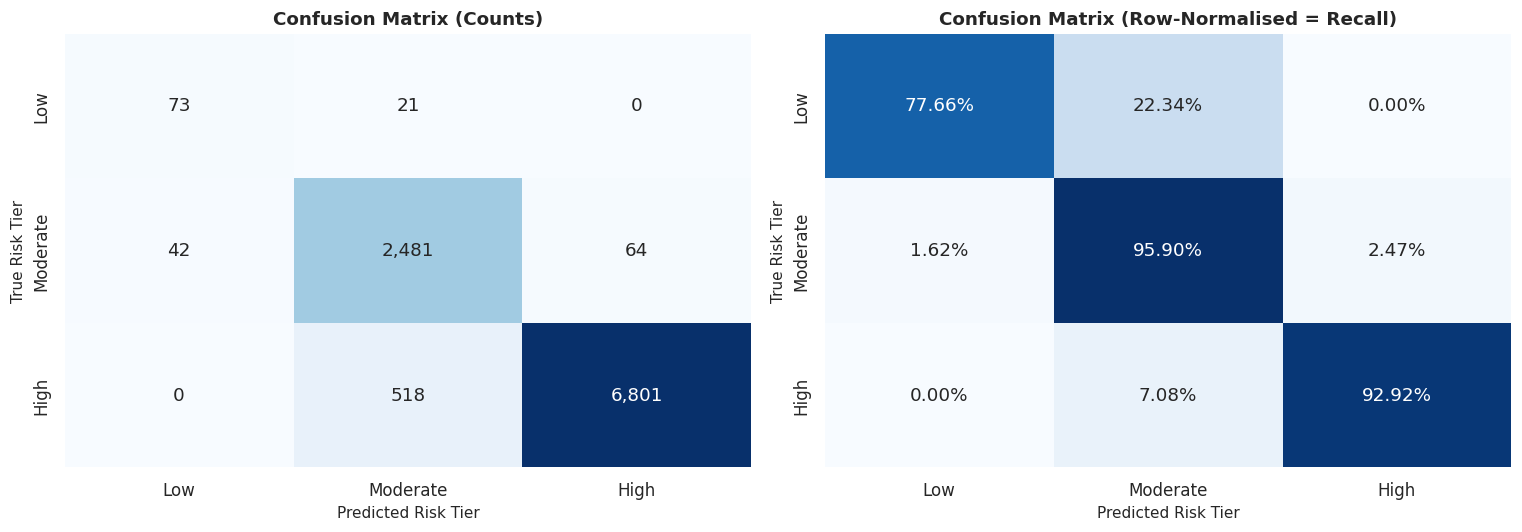

🚨 High-risk patients under-triaged (predicted Low/Moderate): 518 of 7,319 (7.08%)


In [7]:
# Cell 7: Confusion Matrices (Counts & Row-Normalised Recall)
cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
axes[1].set_title('Confusion Matrix (Row-Normalised = Recall)', fontsize=12, fontweight='bold')
for ax in axes:
    ax.set_xlabel('Predicted Risk Tier', fontsize=10)
    ax.set_ylabel('True Risk Tier', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', bbox_inches='tight')
plt.show()

under_triage = cm[LABEL_MAP['High'], :LABEL_MAP['High']].sum()
print(f"🚨 High-risk patients under-triaged (predicted Low/Moderate): {under_triage:,} of {cm[LABEL_MAP['High']].sum():,} "
      f"({under_triage / cm[LABEL_MAP['High']].sum():.2%})")

### 📈 One-vs-Rest ROC & Precision-Recall Curves

ROC curves can look optimistic for a rare class, so we also plot **Precision-Recall** curves — the more honest view for the 0.9%-prevalence `Low` tier.

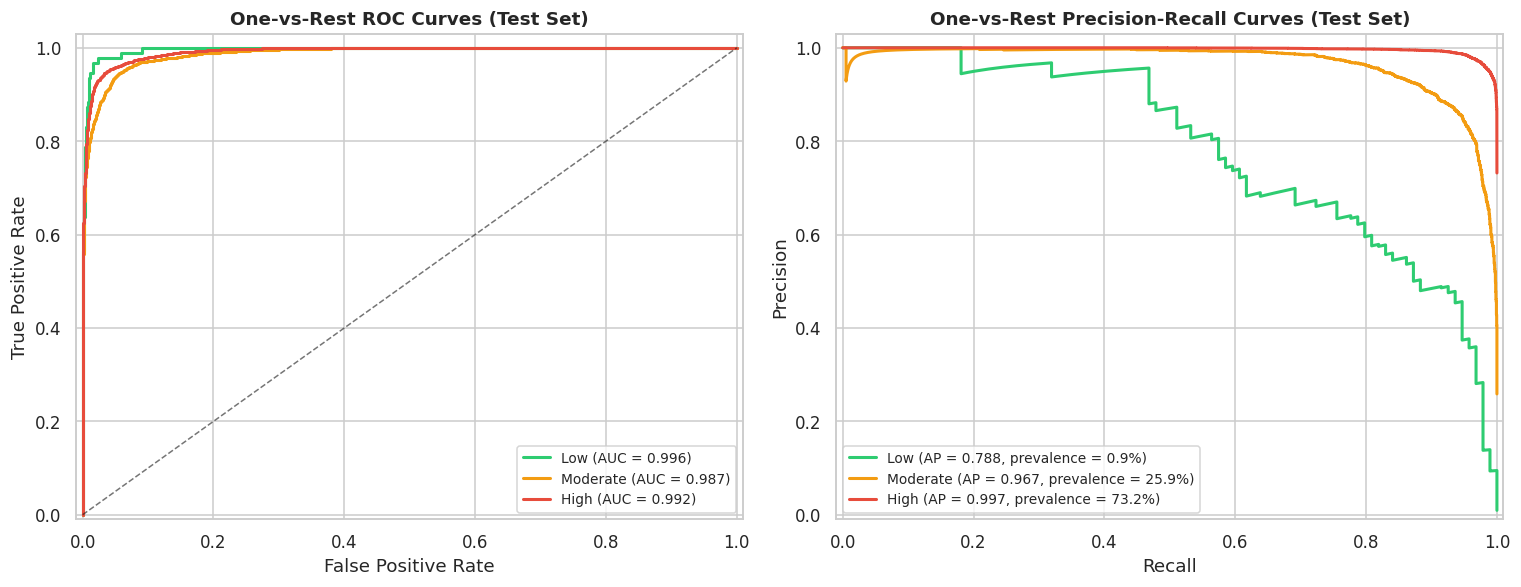

In [8]:
# Cell 8: One-vs-Rest ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for i, tier in enumerate(CLASS_ORDER):
    y_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_proba[:, i])
    prec, rec, _ = precision_recall_curve(y_bin, y_proba[:, i])
    axes[0].plot(fpr, tpr, color=palette[tier], linewidth=2, label=f'{tier} (AUC = {auc(fpr, tpr):.3f})')
    axes[1].plot(rec, prec, color=palette[tier], linewidth=2,
                 label=f'{tier} (AP = {average_precision_score(y_bin, y_proba[:, i]):.3f}, prevalence = {y_bin.mean():.1%})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6)
axes[0].set_title('One-vs-Rest ROC Curves (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[1].set_title('One-vs-Rest Precision-Recall Curves (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
for ax in axes:
    ax.legend(loc='lower right' if ax is axes[0] else 'lower left', fontsize=9)
    ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 6. Model Interpretability: Permutation Feature Importance

Gradient-boosted trees have no single built-in importance that is comparable across feature types, so we use **permutation importance on the test set**: how much macro F1 drops when a feature's values are randomly shuffled. This is model-agnostic and measured on unseen data.

> Note: strongly correlated features (e.g. `HbA1c` and `HbA1c_Glucose_Ratio`, or `BMI` and `Weight_kg`) share credit — shuffling one is partly compensated by the other, so their individual importances can understate their joint value.

⏱️ Permutation importance computed in 105.0s


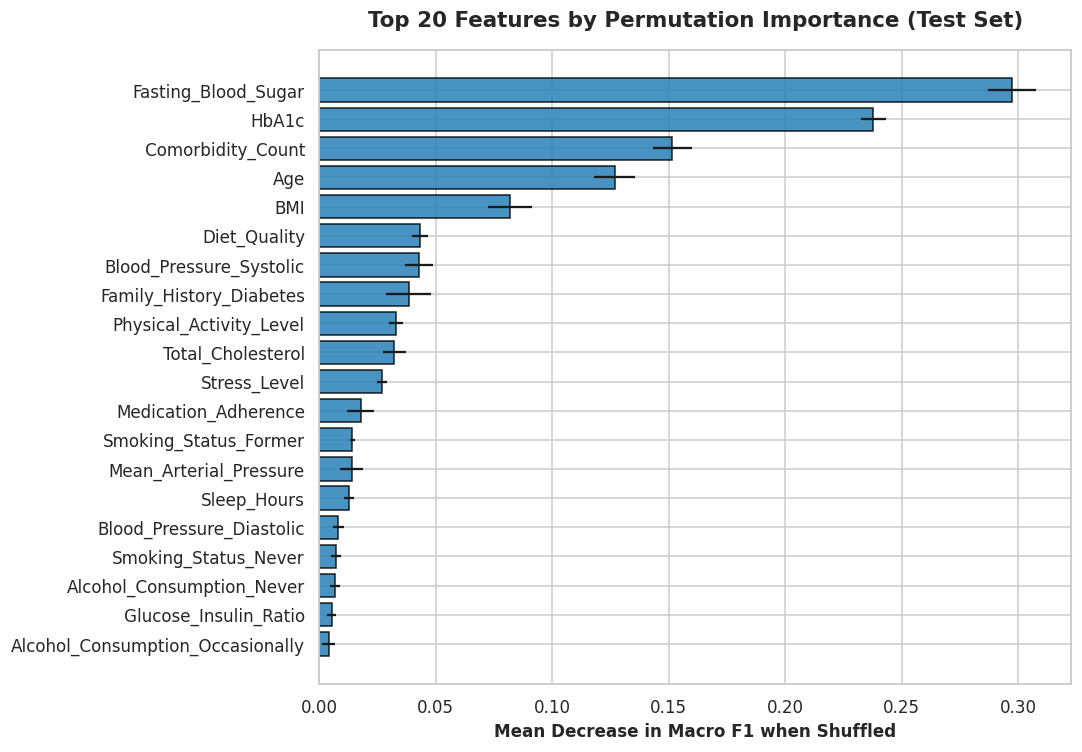

=== TOP 10 FEATURES BY PERMUTATION IMPORTANCE ===


,Feature,Importance (Δ Macro F1),Std
0,Fasting_Blood_Sugar,0.2973,0.0102
1,HbA1c,0.2378,0.0053
2,Comorbidity_Count,0.1515,0.0085
3,Age,0.1268,0.0088
4,BMI,0.0819,0.0096
5,Diet_Quality,0.0432,0.0036
6,Blood_Pressure_Systolic,0.0427,0.0061
7,Family_History_Diabetes,0.0383,0.0095
8,Physical_Activity_Level,0.0328,0.0031
9,Total_Cholesterol,0.0322,0.0049


Features with ~zero or negative importance: 30 of 75


In [9]:
# Cell 9: Permutation Importance on Held-Out Test Set
start = time.time()
perm = permutation_importance(best_model, X_test, y_test, scoring='f1_macro',
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
print(f"⏱️ Permutation importance computed in {time.time() - start:.1f}s")

perm_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance (Δ Macro F1)': perm.importances_mean,
    'Std': perm.importances_std,
}).sort_values('Importance (Δ Macro F1)', ascending=False).reset_index(drop=True)

top = perm_df.head(20)
plt.figure(figsize=(10, 7))
plt.barh(top['Feature'], top['Importance (Δ Macro F1)'], xerr=top['Std'],
         color='#2980b9', edgecolor='black', alpha=0.85)
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Permutation Importance (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mean Decrease in Macro F1 when Shuffled', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'permutation_importance.png', bbox_inches='tight')
plt.show()

print("=== TOP 10 FEATURES BY PERMUTATION IMPORTANCE ===")
display(perm_df.head(10).round(4))
print(f"Features with ~zero or negative importance: {(perm_df['Importance (Δ Macro F1)'] <= 0).sum()} of {len(FEATURES)}")

## 7. Model Export & Final Summary

We persist the tuned model together with a metadata file describing the exact feature order, class labels and evaluation results. The API (`app/main.py`) and `src/predict.py` should load **both** files, so inference uses the same column order the model was trained on.

> ⚠️ The model expects the **engineered & encoded** 75-column matrix produced by notebook 02. For production serving, the feature-engineering and encoding steps should be moved into `src/features.py` so raw patient inputs can be transformed identically.

In [10]:
# Cell 10: Persist Model & Metadata
model_path = MODELS_DIR / 'diabetes_risk_model.pkl'
meta_path = MODELS_DIR / 'model_metadata.json'

joblib.dump(best_model, model_path)

metadata = {
    'model_type': type(best_model).__name__,
    'sklearn_version': sklearn.__version__,
    'target': TARGET,
    'classes': CLASS_ORDER,
    'label_map': LABEL_MAP,
    'features': FEATURES,
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'best_params': {k: (v if v is None or isinstance(v, (int, float, str)) else str(v))
                    for k, v in search.best_params_.items()},
    'cv_macro_f1': round(float(search.best_score_), 4),
    'test_metrics': {k: round(float(v), 4) for k, v in best_metrics.items() if k != 'Model'},
    'random_state': RANDOM_STATE,
}
meta_path.write_text(json.dumps(metadata, indent=2))

# Sanity check: reload and confirm identical predictions
reloaded = joblib.load(model_path)
assert (reloaded.predict(X_test) == y_pred).all()

print(f"💾 Model saved to:    {model_path.relative_to(PROJECT_ROOT)}")
print(f"📝 Metadata saved to: {meta_path.relative_to(PROJECT_ROOT)}")
print("✅ Reload check passed — predictions identical.")
print("\n=== FINAL TEST SET PERFORMANCE ===")
display(test_df.round(4))

💾 Model saved to:    models\diabetes_risk_model.pkl
📝 Metadata saved to: models\model_metadata.json
✅ Reload check passed — predictions identical.

=== FINAL TEST SET PERFORMANCE ===


,Macro F1,Weighted F1,Balanced Accuracy,Accuracy,"ROC-AUC (OvR, macro)"
Model,,,,,
Logistic Regression (baseline),0.6808,0.8507,0.8552,0.8405,0.9489
Tuned Hist Gradient Boosting,0.8475,0.9374,0.8883,0.9355,0.9916


### 📋 Modeling Pipeline Summary

| Stage | Decision | Rationale |
| :--- | :--- | :--- |
| **Split** | Stratified 80/20 train/test | Preserves the 0.9% `Low` tier in both splits |
| **Primary Metric** | Macro F1 (+ balanced accuracy) | Accuracy is inflated by the 73% `High` majority |
| **Imbalance Handling** | `class_weight='balanced'` | Up-weights rare tiers without synthesising patients |
| **Model Selection** | 5-fold stratified CV across 4 candidates | Robust estimate, test set kept untouched |
| **Final Model** | Tuned `HistGradientBoostingClassifier` | Best CV macro F1, fast inference, no extra dependencies |
| **Interpretability** | Permutation importance on test set | Model-agnostic, measured on unseen patients |
| **Artifacts** | `models/diabetes_risk_model.pkl` + `model_metadata.json` | Ready for `src/predict.py` and the FastAPI service |

### 🔜 Next Steps
1. Port the cleaning, feature-engineering and encoding logic from notebooks 01–02 into `src/data.py` / `src/features.py`, and wrap them with the model in a single `sklearn` `Pipeline` so the API can accept raw patient fields.
2. Fit imputation statistics on the training split only (notebook 01 currently imputes medians on the full dataset — a minor form of leakage).
3. Consider probability calibration and a decision threshold that minimises `High`-risk under-triage.